#### Deepdive into fundamentals of deep learning

In [15]:
# !nvidia-smi
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from Preprocessing import standard_scaler,label_encoder,_train_test_split # custum module

     Exploratory_data_analysis 

In [16]:
# Dataloading
# dataset with features : 3000x4 ->> 3class
df = pd.read_csv('Dataset/iris_synthetic_data.csv')
matrix = df[['sepal length','sepal width','petal length','petal width']].corr()
df.sample(5)
print(df.describe())
print(df.info())

       sepal length  sepal width  petal length  petal width
count   3000.000000  3000.000000   3000.000000  3000.000000
mean       5.865267     3.051833      3.767367     1.191000
std        0.805073     0.412472      1.751183     0.758022
min        4.300000     2.000000      0.900000     0.100000
25%        5.100000     2.800000      1.500000     0.300000
50%        5.800000     3.000000      4.300000     1.300000
75%        6.400000     3.300000      5.200000     1.800000
max        7.900000     4.400000      6.900000     2.500000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal length  3000 non-null   float64
 1   sepal width   3000 non-null   float64
 2   petal length  3000 non-null   float64
 3   petal width   3000 non-null   float64
 4   label         3000 non-null   object 
dtypes: float64(4), object(1)
memory usage: 117.3+ KB

[]

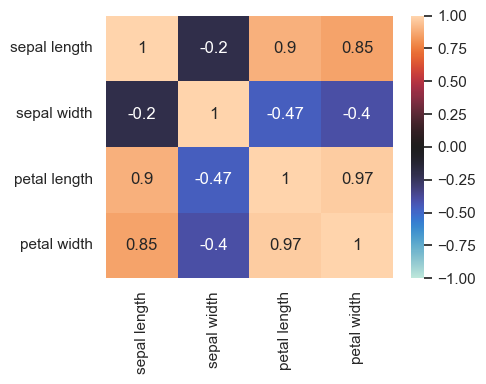

In [17]:
# heatmap
sns.set_theme(style="dark")
plt.figure(figsize=(5,4))
sns.heatmap(matrix,annot=True,cmap="icefire",vmin=-1,vmax=1)
# plt.title("Highly correlated features!")
plt.tight_layout()
plt.plot()

    Preprocessing
-> *Data splitting, feature scaling using standard_scaler and label encoding*

In [18]:
"""
using standard_scaler, encoder and train_test_split model from custom module(Preprocessing)
"""
# Data_split()
X=df.iloc[:,:-1]
Y=df.iloc[:,-1]
x_train_uns,x_test_uns,y_train_unl,y_test_unl = _train_test_split(X,Y,0.25)
x_train_uns.shape,x_test_uns.shape,y_train_unl.shape,y_test_unl.shape

((2250, 4), (750, 4), (2250,), (750,))

In [19]:
# scaling features and encoding labels
scaler = standard_scaler()
encoder= label_encoder()

x_train=scaler.fit_transform(x_train_uns)   # calculate mean,std of train data and transform
x_test=scaler.transform(x_test_uns)  # use mean,std from train data to transform test. it avoids data leakage and perform better on real world data

y_train=encoder.fit_transform(y_train_unl)
y_test=encoder.fit_transform(y_test_unl)

x_train[:6],x_test[:6],y_train[:20],y_test[:20]

{'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}
{'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}


(array([[-7.10228604e-01, -1.34733281e+00, -2.30483023e-01,
         -2.35583313e-03],
        [-8.33228477e-01,  1.84526965e+00, -1.31539265e+00,
         -1.19499635e+00],
        [-5.87228730e-01,  2.09085445e+00, -1.25829214e+00,
         -1.06248074e+00],
        [-9.52292355e-02, -8.56163203e-01,  5.50195104e-02,
         -2.35583313e-03],
        [-5.87228730e-01,  2.82760887e+00, -1.31539265e+00,
         -1.32751197e+00],
        [ 1.50376912e+00, -1.19408789e-01,  1.19702964e+00,
          1.19028469e+00]]),
 array([[-1.69422759,  0.37176082, -1.42959366, -1.32751197],
        [-1.32522797,  0.12617602, -1.25829214, -1.32751197],
        [ 0.39677026, -0.8561632 ,  0.96862762,  0.26267539],
        [-0.09522924, -0.8561632 ,  0.05501951, -0.13487145],
        [-0.46422886, -1.59291762,  0.05501951, -0.13487145],
        [-1.07922822,  0.86293043, -1.31539265, -1.32751197]]),
 array([1, 0, 0, 1, 0, 2, 2, 1, 1, 1, 1, 2, 2, 0, 1, 1, 2, 2, 2, 2]),
 array([0, 0, 2, 1, 1, 0, 2, 1, 

    Model_implementaion

In [20]:
# onlyscratch
class param_:
    def __init__(self,n_features,n_class):
        np.random.seed(16)

        self.wh1 = np.random.randn(n_features,n_features-1)* np.sqrt(2/n_features).astype('float32')
        self.wh2 = np.random.randn(n_features-1,n_features-2)*np.sqrt(2/(n_features-1)).astype('float32')
        self.wOut = np.random.randn(n_features-2,n_class)*np.sqrt(2/(n_features-2)).astype('float32')
        # self.wOut = np.random.rand()
        self.bh1= np.random.randn((n_features-1))*np.sqrt(2/(n_features-1)).astype('float32'),
        self.bh2= np.random.randn((n_features-2))*np.sqrt(2/(n_features-2)).astype('float32'),
        self.bOut= np.random.randn((n_class))*np.sqrt(2/(n_class)).astype('float32')

class multiclassifier(param_):
    def __init__(self,features,labels, l_r= 1e-2):
        super().__init__(features.shape[1],3)
        self.labels=labels
        self.features=features
        self.l_r = l_r

        # print(self.n1.wInp,"\n",self.n1.wh1,"\n",self.n1.wh2)

    def softmax(self,x):
        z= np.exp(x-np.max(x,axis=1,keepdims= True))       # or exp(x)/sum(exp(x),axis=1)
        return z/np.sum(z,axis=1,keepdims=True)
        # print((np.exp(-x)[:,0]/z).shape)

    def forwardProp(self):
        # layer 1 logits
        y1 = self.features@self.wh1 + self.bh1
        y1 = np.maximum(0,y1)  # ReLU activation
        
        y2 = y1@self.wh2 + self.bh2
        y2 = np.maximum(0,y2)  # ReLU activation
    
        y3 = y2@self.wOut + self.bOut
        y3 = self.softmax(y3)
        return y3
    
    
    def backwardProp(self):
        # loss CrossEntropyLoss
        z = self.forwardProp()[np.arange(self.labels.shape[0]),self.labels] + 1e-11
        loss = np.mean(-1*np.log(z),keepdims=True) # total loss from every parameter
        return loss



obj = multiclassifier(x_train,y_train)
x = obj.backwardProp()
x

array([1.47629555])

In [21]:
# import os
# print(os.getcwd())
np.sqrt(1/3)

np.float64(0.5773502691896257)

In [22]:
# print(os.listdir())